In [1]:
%%html
<style>
table {display: inline-block}
td {text-align:left}
.consoleMachineFont {color:blue;font-family:Courier}
.consoleUserFont {font-family:Courier}
</style>

# SciPy

## Recitation Goals

In the lecture, SciPy was used for fitting, ODE simulation, and PCA. In this recitation we will use SciPy for a different kind of chemical problem: solving equilibrium equations.

We will practice how to:

1. write a chemical equilibrium condition as a numerical function,
2. use `root_scalar` to find a physically meaningful pH,
3. compare one result with a familiar weak-acid approximation,
4. build a weak-acid titration curve with the same solver,
5. use interpolation to answer a question from a computed curve.

The main idea is not the titration formula itself. The main idea is that SciPy can find numbers that satisfy scientific conditions when solving by hand becomes awkward.


## Imports

We will use NumPy for arrays, Matplotlib for plots, and two SciPy tools:

- `root_scalar` finds a zero of a function of one variable, bracketed between two values.
- `interp1d` builds a simple interpolating function from computed data.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d

## 1. A Weak Acid as a Root-Finding Problem

Consider acetic acid:

$$
\mathrm{HA \rightleftharpoons H^+ + A^-}
$$

with

$$
K_a = \frac{[H^+][A^-]}{[HA]}.
$$

For a solution with total acid concentration $C_\mathrm{acid}$, mass balance gives:

$$
C_\mathrm{acid} = [HA] + [A^-].
$$

Combining this with the equilibrium expression gives $[A^-]$ as a function of $[H^+]$:

$$
[A^-] = C_\mathrm{acid} \frac{K_a}{[H^+] + K_a}.
$$

We will write the charge balance in a slightly general form, allowing for sodium ions from added NaOH:

$$
[H^+] + [Na^+] = [OH^-] + [A^-].
$$

The first example is just acetic acid in water, so no NaOH has been added yet and $[Na^+] = 0$. Later, the titration will use the same equation with a nonzero sodium concentration.


### Writing the Function Whose Root We Need

`root_scalar` expects a function that is zero at the answer. We will use pH as the variable because it is easier to bracket chemically: most ordinary aqueous pH values lie between 0 and 14.

Define:

$$
f(\mathrm{pH}) = [H^+] + [Na^+] - [OH^-] - [A^-].
$$

The correct pH is the value where $f(\mathrm{pH}) = 0$. The default value `sodium_concentration=0.0` represents the acid-only solution.


In [3]:
Ka_acetic = 1.8e-5  # acid dissociation constant of acetic acid at 25 C
Kw = 1.0e-14       # ion product of water at 25 C


def charge_balance(pH, acid_total, sodium_concentration=0.0, Ka=Ka_acetic, Kw=Kw):
    H = 10 ** (-pH)
    OH = Kw / H
    A_minus = acid_total * Ka / (H + Ka)
    return H + sodium_concentration - OH - A_minus


Before solving, inspect the function at two pH values. A sign change tells us that the root lies between them.

In [4]:
acid_concentration = 0.10
sodium_concentration = 0.0  # no NaOH has been added in the first example

low_pH = 0.0
high_pH = 14.0

print(charge_balance(low_pH, acid_concentration, sodium_concentration))
print(charge_balance(high_pH, acid_concentration, sodium_concentration))


0.9999982000323894
-1.0999999999444345


The values have opposite signs, so SciPy can search inside this bracket.

In [5]:
def solve_pH(acid_total, sodium_concentration=0.0, Ka=Ka_acetic, Kw=Kw):
    solution = root_scalar(
        charge_balance,
        args=(acid_total, sodium_concentration, Ka, Kw),
        bracket=[0.0, 14.0],
        method="brentq",
    )
    return solution.root


pH_numerical = solve_pH(acid_concentration)
print(pH_numerical)


2.8752770603192706


### A Quick Comparison with the Usual Approximation

For a weak acid, a common approximation is:

$$
[H^+] \approx \sqrt{K_a C_\mathrm{acid}}.
$$

For this concentration it is close, but the numerical method did not require making that approximation.

In [6]:
H_approx = np.sqrt(Ka_acetic * acid_concentration)
pH_approx = -np.log10(H_approx)

print(f"numerical pH:   {pH_numerical:.3f}")
print(f"approximate pH: {pH_approx:.3f}")

numerical pH:   2.875
approximate pH: 2.872


## 2. Adding Strong Base: Same Solver, New Sodium Concentration

Now titrate 25.0 mL of 0.100 M acetic acid with 0.100 M NaOH.

After mixing, two analytical concentrations are important:

- `acid_total`: total concentration of acetic-acid species, $[HA] + [A^-]$.
- `sodium_concentration`: concentration of sodium ions from the added NaOH.

The chemistry has changed because NaOH adds sodium and consumes acid, but the numerical problem has not changed. We still solve the same charge balance:

$$
[H^+] + [Na^+] = [OH^-] + [A^-].
$$

Before equivalence, near equivalence, and after equivalence, only the concentration values passed to `solve_pH` change.


## 3. Building the Titration Curve

We'll make a function that calculates the post-mixing acid and sodium concentrations:

In [7]:
acid_volume_L = 25.0e-3  # initial acid volume, L
acid_initial_M = 0.100   # initial acetic acid concentration, mol/L
base_M = 0.100           # NaOH concentration, mol/L

acid_moles_initial = acid_initial_M * acid_volume_L


def concentrations_after_mixing(base_volume_L):
    total_volume_L = acid_volume_L + base_volume_L
    acid_total = acid_moles_initial / total_volume_L
    sodium_concentration = base_M * base_volume_L / total_volume_L
    return acid_total, sodium_concentration

Now we loop over a set of base volumes and collect the results:

In [8]:
base_volumes_mL = np.linspace(0.0, 45.0, 181)
pH_values = []

for base_volume_mL in base_volumes_mL:
    acid_total, sodium_concentration = concentrations_after_mixing(base_volume_mL / 1000)
    pH = solve_pH(acid_total, sodium_concentration)
    pH_values.append(pH)

pH_values = np.array(pH_values)

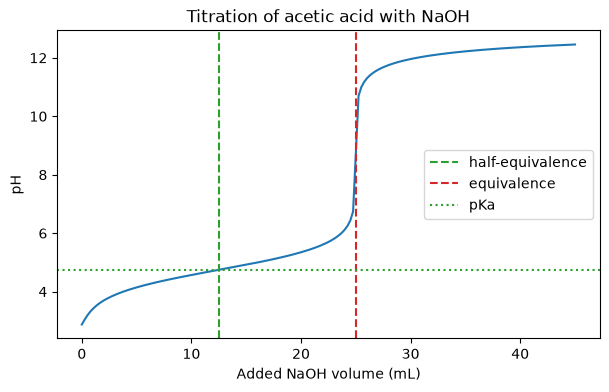

In [9]:
equivalence_volume_mL = acid_moles_initial / base_M * 1000
half_equivalence_volume_mL = equivalence_volume_mL / 2
pKa = -np.log10(Ka_acetic)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(base_volumes_mL, pH_values)
ax.axvline(half_equivalence_volume_mL, color="tab:green", linestyle="--", label="half-equivalence")
ax.axvline(equivalence_volume_mL, color="tab:red", linestyle="--", label="equivalence")
ax.axhline(pKa, color="tab:green", linestyle=":", label="pKa")
ax.set_xlabel("Added NaOH volume (mL)")
ax.set_ylabel("pH")
ax.set_title("Titration of acetic acid with NaOH")
ax.legend()
plt.show()

The plot matches chemical expectations:

- the pH starts acidic,
- the buffer region changes slowly,
- the curve rises sharply near equivalence,
- the equivalence point is above pH 7.

The important computational point is that the same root-finding function produced every point on the curve.

## 4. Interpolation: When Does the Solution Reach pH 7?

The computed curve is an array of pH values at specific volumes. If we want the volume where pH is exactly 7.00, that point may lie between two computed volumes. In general, it could be expensive to obtain many points and get an accurate result, so it makes sense to draw a curve based on the discrete data points we have.

Interpolation (linear in this case) does exactly that: it creates a curve from the computed points by connecting them with straight lines. Because the curve is increasing, we can build a function that maps pH to volume.

In [10]:
order = np.argsort(pH_values)
pH_sorted = pH_values[order]
volume_sorted = base_volumes_mL[order]

pH_to_volume = interp1d(pH_sorted, volume_sorted)
volume_at_pH_7 = float(pH_to_volume(7.00))

print(f"Volume at pH 7.00: {volume_at_pH_7:.2f} mL")
print(f"Equivalence volume: {equivalence_volume_mL:.2f} mL")

Volume at pH 7.00: 24.78 mL
Equivalence volume: 25.00 mL


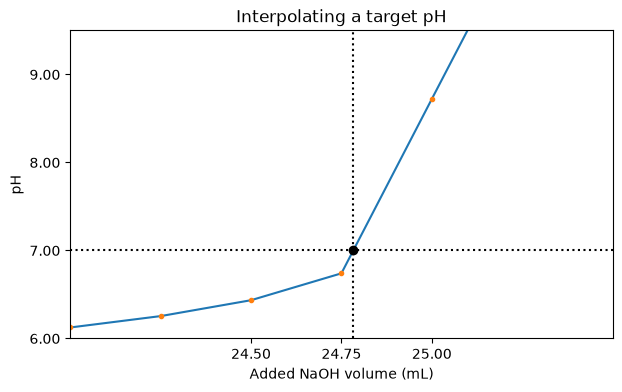

In [63]:
# Visualizing the interpolation with matplotlib:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(base_volumes_mL, pH_values)
ax.plot(base_volumes_mL, pH_values, '.', 'red')
ax.scatter(volume_at_pH_7, 7.00, color="black", zorder=3)

# Zoom in and set ticks manually:
ax.set_xlim(24,25.5)
xticks = [24, 24.5, volume_at_pH_7, 25, 25.5]
tick_labels = [f"{x:.2f}" for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(tick_labels)
ax.set_ylim(6,9.5)
yticks = [6, 7, 8, 9]
tick_labels = [f"{x:.2f}" for x in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(tick_labels)


ax.axhline(7.00, color="black", linestyle=":")
ax.axvline(volume_at_pH_7, color="black", linestyle=":")
ax.set_xlabel("Added NaOH volume (mL)")
ax.set_ylabel("pH")
ax.set_title("Interpolating a target pH")
plt.show()

## Practice Questions

1. Change the acid concentration to 0.010 M. How does the initial pH change?
2. Change `Ka_acetic` to the $K_a$ of a stronger or weaker acid. What happens to the half-equivalence pH?
3. Increase the number of volume points in `base_volumes_mL`. Does the interpolated volume at pH 7.00 change much?
4. Try a different target pH, such as 5.00 or 9.00. Is interpolation equally reliable everywhere on the curve?

The last question is subtle: interpolation is most reliable where the computed curve has enough points to describe the local shape.
